In [1]:
import warnings

warnings.filterwarnings("ignore")

In [2]:
import pandas as pd
import numpy as np

# Summarization


### The CNN/DailyMail Dataset

In [3]:
from datasets import load_dataset

dataset = load_dataset("abisee/cnn_dailymail", "3.0.0")
print(f"Features:{dataset['train'].column_names}")

README.md: 0.00B [00:00, ?B/s]

3.0.0/train-00000-of-00003.parquet:   0%|          | 0.00/257M [00:00<?, ?B/s]

3.0.0/train-00001-of-00003.parquet:   0%|          | 0.00/257M [00:00<?, ?B/s]

3.0.0/train-00002-of-00003.parquet:   0%|          | 0.00/259M [00:00<?, ?B/s]

3.0.0/validation-00000-of-00001.parquet:   0%|          | 0.00/34.7M [00:00<?, ?B/s]

3.0.0/test-00000-of-00001.parquet:   0%|          | 0.00/30.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/287113 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/13368 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/11490 [00:00<?, ? examples/s]

Features:['article', 'highlights', 'id']


In [4]:
sample = dataset["train"][1]
print(
    f"""
      Article (except of 500 characters , total length:{len(sample["article"])}):
      """
)
print(sample["article"][:500])
print(f'\nSummary (length: {len(sample["highlights"])}):')
print(sample["highlights"])


      Article (except of 500 characters , total length:4051):
      
Editor's note: In our Behind the Scenes series, CNN correspondents share their experiences in covering news and analyze the stories behind the events. Here, Soledad O'Brien takes users inside a jail where many of the inmates are mentally ill. An inmate housed on the "forgotten floor," where many mentally ill inmates are housed in Miami before trial. MIAMI, Florida (CNN) -- The ninth floor of the Miami-Dade pretrial detention facility is dubbed the "forgotten floor." Here, inmates with the most s

Summary (length: 281):
Mentally ill inmates in Miami are housed on the "forgotten floor"
Judge Steven Leifman says most are there as a result of "avoidable felonies"
While CNN tours facility, patient shouts: "I am the son of the president"
Leifman says the system is unjust and he's fighting for change .


### Text Summarization Pipelines

In [5]:
sample_text = dataset["train"][1]["article"][:2000]
summaries = {}
sample_text

'Editor\'s note: In our Behind the Scenes series, CNN correspondents share their experiences in covering news and analyze the stories behind the events. Here, Soledad O\'Brien takes users inside a jail where many of the inmates are mentally ill. An inmate housed on the "forgotten floor," where many mentally ill inmates are housed in Miami before trial. MIAMI, Florida (CNN) -- The ninth floor of the Miami-Dade pretrial detention facility is dubbed the "forgotten floor." Here, inmates with the most severe mental illnesses are incarcerated until they\'re ready to appear in court. Most often, they face drug charges or charges of assaulting an officer --charges that Judge Steven Leifman says are usually "avoidable felonies." He says the arrests often result from confrontations with police. Mentally ill people often won\'t do what they\'re told when police arrive on the scene -- confrontation seems to exacerbate their illness and they become more paranoid, delusional, and less likely to foll

In [ ]:
%pip install nltk

In [6]:
import nltk
from nltk.tokenize import sent_tokenize

nltk.download("punkt")
string = "The U.S are a country. The U.N is an organization."
sent_tokenize(string)

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


['The U.S are a country.', 'The U.N is an organization.']

#### Summarization Baseline

In [7]:
def three_sentence_summary(text):
    return "\n".join(sent_tokenize(text)[:3])


summaries["baseline"] = three_sentence_summary(sample_text)

### GPT-2

In [12]:
from transformers import pipeline, set_seed

set_seed(42)
pipe = pipeline("text-generation", model="openai-community/gpt2")
gpt2_query = sample_text + "\nTL;DR:\n"
pipe_out = pipe(gpt2_query, max_length=512, clean_up_tokenization_spaces=True)
summaries["gpt2"] = "\n".join(
    sent_tokenize(pipe_out[0]["generated_text"][len(gpt2_query) :])
)

2025-09-24 15:13:18.166581: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1758726798.393913      60 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1758726798.459764      60 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cuda:0
Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


#### T5

In [ ]:
pipe = pipeline("summarization", model="t5-large")
pipe_out = pipe(sample_text)
summaries["t5"] = "\n".join(sent_tokenize(pipe_out[0]["summary_text"]))

#### Bert

In [ ]:
pipe = pipeline("summarization", model="facebook/bart-large-cnn")
pipe_out = pipe(sample_text)
summaries["bert"] = "\n".join(sent_tokenize(pipe_out[0]["summary_text"]))

#### PEGASUS

In [11]:
pipe = pipeline("summarization", model="google/pegasus-cnn_dailymail")
pipe_out = pipe(sample_text)
summaries["pegasus"] = pipe_out[0]["summary_text"].replace(" .<n>", "\n")

NameError: name 'pipeline' is not defined

### Comparing Different Summaries

In [ ]:
print("GROUND TRUTH")
print(dataset["train"][1]["highlights"])
print("")
for model_name in summaries:
    print(model_name.upper())
    print(summaries[model_name])
    print("")

### Measuring the Quality of Generated Text

BLEU

In [8]:
%pip install evaluate sacrebleu rouge-score

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 2.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 12.2 MB/s eta 0:00:00
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=fdfa1e53ab7859073994fb099674df6aa1d60ae20634ecbbdaaf29e8077fa736
  Stored in directory: /root/.cache/pip/wheels/1e/19/43/8a442dc83660ca25e163e1bd1f89919284ab0d0c1475475148
Successfully built rouge-score
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.5.1
    Uninstalling fsspec-2025.5.1:
      Successfully uninstalled fsspec-2025.5.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigfra

In [ ]:
import evaluate

bleu_metric = evaluate.load("sacrebleu")

In [ ]:
import pandas as pd
import numpy as np

bleu_metric.add(
    prediction="the the the the the the", reference=["the cat is on the mat"]
)
results = bleu_metric.compute(smooth_method="floor", smooth_value=0)
results["precisions"] = [np.round(p, 2) for p in results["precisions"]]
pd.DataFrame.from_dict(results, orient="index", columns=["value"])

In [ ]:
bleu_metric.add(prediction="the cat is on met", reference=["the cat is on the mat"])
results = bleu_metric.compute(smooth_method="floor", smooth_value=0)
results["precisions"] = [np.round(p, 2) for p in results["precisions"]]
pd.DataFrame.from_dict(results, orient="index", columns=["value"])

### ROUGE

In [20]:
import evaluate

rouge_metric = evaluate.load("rouge")

In [21]:
reference = dataset["train"][1]["highlights"]
records = []
rouge_names = ["rouge1", "rouge2", "rougeL", "rougeLsum"]

for model_name in summaries:
    rouge_metric.add(prediction=summaries[model_name], reference=reference)
    score = rouge_metric.compute()
    rouge_dict = dict((rn, score[rn]) for rn in rouge_names)
    records.append(rouge_dict)
pd.DataFrame.from_records(records, index=summaries.keys())

,rouge1,rouge2,rougeL,rougeLsum
baseline,0.365079,0.145161,0.206349,0.285714
gpt2,0.154762,0.024096,0.119048,0.154762


### Evaluating PEGASUS on the CNN/DailyMail Dataset

In [18]:
def evaluate_summaries_baseline(
    dataset, metric, column_text="article", column_summary="highlights"
):
    summaries = [three_sentence_summary(text) for text in dataset[column_text]]
    metric.add_batch(predictions=summaries, references=dataset[column_summary])
    score = metric.compute()
    return score

In [22]:
test_sampled = dataset["test"].shuffle(seed=42).select(range(1000))

score = evaluate_summaries_baseline(test_sampled, rouge_metric)
rouge_dict = dict((rn, score[rn]) for rn in rouge_names)
pd.DataFrame.from_dict(rouge_dict, orient="index", columns=["baseline"]).T

,rouge1,rouge2,rougeL,rougeLsum
baseline,0.389276,0.171296,0.245061,0.354239


In [23]:
from tqdm import tqdm
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"


def chunks(list_of_elements, batch_size):
    """Yield successive batch-sized chunks from list_of_elements."""
    for i in range(0, len(list_of_elements), batch_size):
        yield list_of_elements[i : i + batch_size]


def evaluate_summaries_pegasus(
    dataset,
    metric,
    model,
    tokenizer,
    batch_size=16,
    device=device,
    column_text="article",
    column_summary="highlights",
):
    article_batches = list(chunks(dataset[column_text], batch_size))
    target_batches = list(chunks(dataset[column_summary], batch_size))

    for article_batch, target_batch in tqdm(
        zip(article_batches, target_batches), total=len(article_batches)
    ):
        inputs = tokenizer(
            article_batch,
            max_length=1024,
            truncation=True,
            padding="max_length",
            return_tensors="pt",
        )
        summaries = model.generate(
            input_ids=inputs["input_ids"].to(device),
            attention_mask=inputs["attention_mask"].to(device),
            length_penalty=0.8,
            num_beams=8,
            max_length=128,
        )
        decoded_summaries = [
            tokenizer.decode(
                s, skip_special_tokens=True, clean_up_tokenization_spaces=True
            )
            for s in summaries
        ]
        decoded_summaries = [d.replace("", " ") for d in decoded_summaries]
        metric.add_batch(predictions=decoded_summaries, references=target_batch)
    score = metric.compute()
    return score

In [24]:
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer

model_ckpt = "google/pegasus-cnn_dailymail"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)
model = AutoModelForSeq2SeqLM.from_pretrained(model_ckpt, device_map="auto").to(device)
score = evaluate_summaries_pegasus(
    test_sampled, rouge_metric, model, tokenizer, batch_size=8
)
rouge_dict = dict((rn, score[rn]) for rn in rouge_names)
pd.DataFrame(rouge_dict, index=["pegasus"])

Some weights of PegasusForConditionalGeneration were not initialized from the model checkpoint at google/pegasus-cnn_dailymail and are newly initialized: ['model.decoder.embed_positions.weight', 'model.encoder.embed_positions.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
100%|██████████| 125/125 [26:23<00:00, 12.67s/it]


,rouge1,rouge2,rougeL,rougeLsum
pegasus,0.012331,0.00052,0.01222,0.012318


In [ ]:
pd.DataFrame(rouge_dict, index=["pegasus"])

### Training A Summarization Model

In [9]:
dataset_samsum = load_dataset("knkarthick/dialogsum")

split_lengths = [len(dataset_samsum[split]) for split in dataset_samsum]

print(f"Split lengths: {split_lengths}")
print(f"Features: {dataset_samsum['train'].column_names}")
print("\nDialogue:")
print(dataset_samsum["test"][0]["dialogue"])
print("\nSummary:")
print(dataset_samsum["test"][0]["summary"])

print(f"Split lengths: {split_lengths}")
print(f"Features: {dataset_samsum['train'].column_names}")
print("\nDialogue:")
print(dataset_samsum["test"][0]["dialogue"])
print("\nSummary:")
print(dataset_samsum["test"][0]["summary"])

README.md: 0.00B [00:00, ?B/s]

train.csv:   0%|          | 0.00/11.3M [00:00<?, ?B/s]

validation.csv: 0.00B [00:00, ?B/s]

test.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/12460 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/500 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1500 [00:00<?, ? examples/s]

Split lengths: [12460, 500, 1500]
Features: ['id', 'dialogue', 'summary', 'topic']

Dialogue:
#Person1#: Ms. Dawson, I need you to take a dictation for me.
#Person2#: Yes, sir...
#Person1#: This should go out as an intra-office memorandum to all employees by this afternoon. Are you ready?
#Person2#: Yes, sir. Go ahead.
#Person1#: Attention all staff... Effective immediately, all office communications are restricted to email correspondence and official memos. The use of Instant Message programs by employees during working hours is strictly prohibited.
#Person2#: Sir, does this apply to intra-office communications only? Or will it also restrict external communications?
#Person1#: It should apply to all communications, not only in this office between employees, but also any outside communications.
#Person2#: But sir, many employees use Instant Messaging to communicate with their clients.
#Person1#: They will just have to change their communication methods. I don't want any - one using Ins

### Evaluating PEGASUS on Dialogsum

In [13]:
pipe_out = pipe(dataset_samsum["test"][0]["dialogue"])
print("summary:")
summary = (
    pipe_out[0].get("summary_text")
    or pipe_out[0].get("generated_text")
    or pipe_out[0].get("text")
)
print(summary.replace(" .<n>", ".\n"))

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


summary:
#Person1#: Ms. Dawson, I need you to take a dictation for me.
#Person2#: Yes, sir...
#Person1#: This should go out as an intra-office memorandum to all employees by this afternoon. Are you ready?
#Person2#: Yes, sir. Go ahead.
#Person1#: Attention all staff... Effective immediately, all office communications are restricted to email correspondence and official memos. The use of Instant Message programs by employees during working hours is strictly prohibited.
#Person2#: Sir, does this apply to intra-office communications only? Or will it also restrict external communications?
#Person1#: It should apply to all communications, not only in this office between employees, but also any outside communications.
#Person2#: But sir, many employees use Instant Messaging to communicate with their clients.
#Person1#: They will just have to change their communication methods. I don't want any - one using Instant Messaging in this office. It wastes too much time! Now, please continue with the

In [25]:
score = evaluate_summaries_pegasus(
    dataset_samsum["test"],
    rouge_metric,
    model,
    tokenizer,
    column_text="dialogue",
    column_summary="summary",
    batch_size=8,
)
rouge_dict = dict((rn, score[rn]) for rn in rouge_names)
pd.DataFrame(rouge_dict, index=["pegasus"])

100%|██████████| 188/188 [32:49<00:00, 10.48s/it]


,rouge1,rouge2,rougeL,rougeLsum
pegasus,0.011744,0.000146,0.011735,0.011727


### Fine Tunning PEGASUS 

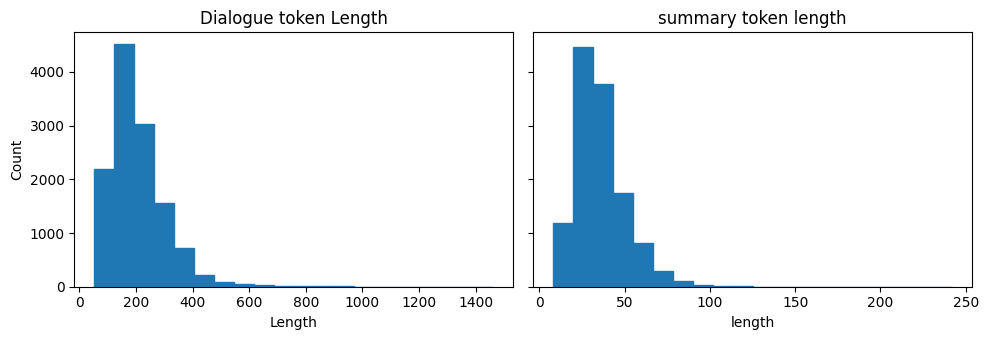

In [28]:
d_len=[len(tokenizer.encode(s)) for s in dataset_samsum["train"]["dialogue"]]
s_len=[len(tokenizer.encode(s)) for s in dataset_samsum["train"]["summary"]]
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1,2,figsize=(10,3.5),sharey=True)
axes[0].hist(d_len,bins=20,color="C0",edgecolor = "C0")
axes[0].set_title("Dialogue token Length")
axes[0].set_xlabel("Length")
axes[0].set_ylabel("Count")
axes[1].hist(s_len,bins=20,color="C0",edgecolor="C0")
axes[1].set_title("summary token length")
axes[1].set_xlabel("length")
plt.tight_layout()
plt.show()

In [31]:
def convert_examples_to_features(example_batch):
    input_encodings = tokenizer(example_batch["dialogue"],max_length= 1024,truncation=True)
    with tokenizer.as_target_tokenizer():
        target_encodings = tokenizer(example_batch["summary"],max_length= 128,truncation=True)
        return {"input_ids":input_encodings["input_ids"],"attention_mask":input_encodings["attention_mask"],"labels":target_encodings["input_ids"]}
dataset_samsum_pt = dataset_samsum.map(convert_examples_to_features,batched=True)
columns= ["input_ids","labels","attention_mask"]
dataset_samsum_pt.set_format(type="torch",columns=columns)

Map:   0%|          | 0/12460 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

In [32]:
from transformers import DataCollatorForSeq2Seq

seq2seq_data_collator = DataCollatorForSeq2Seq(tokenizer,model=model)


In [38]:
from transformers import TrainingArguments,Trainer

training_args= TrainingArguments(
    output_dir="pegasus-knkarthick_dialogsum",num_train_epochs=1,warmup_steps=500,
    per_device_train_batch_size=1,per_device_eval_batch_size=1,
    weight_decay=0.01,logging_steps=10,push_to_hub=True,
    eval_strategy="steps",eval_steps = 500,save_steps = 1e6,
    gradient_accumulation_steps=16,
    report_to="none"
)

In [ ]:
from huggingface_hub import login
login("Enter_your_token")

In [40]:
trainer = Trainer(model=model,args = training_args,tokenizer=tokenizer,data_collator = seq2seq_data_collator,
                  train_dataset=dataset_samsum_pt["train"],
                  eval_dataset=dataset_samsum_pt["validation"])

In [41]:
trainer.train()
score = evaluate_summaries_pegasus(
    dataset_samsum["test"],rouge_metric,trainer.model,tokenizer,
    batch_size=2,column_text="dialogue",column_summary="summary"
)
rouge_dict = dict((rn,score[rn]) for rn in rouge_names)
pd.DataFrame(rouge_dict,index=[f"pegasus"])

Step,Training Loss,Validation Loss
500,1.224800,1.160970


100%|██████████| 750/750 [24:42<00:00,  1.98s/it]


,rouge1,rouge2,rougeL,rougeLsum
pegasus,0.015831,0.000243,0.015798,0.015793


In [42]:
trainer.push_to_hub("Training Pegasus with knkarthick-dialogsum")

Uploading...:   0%|          | 0.00/2.29G [00:00<?, ?B/s]

CommitInfo(commit_url='https://huggingface.co/swamimanish/pegasus-knkarthick_dialogsum/commit/2205d6cc6d38fd34e3586fb3e6cdc017d4c09be5', commit_message='Training Pegasus with knkarthick-dialogsum', commit_description='', oid='2205d6cc6d38fd34e3586fb3e6cdc017d4c09be5', pr_url=None, repo_url=RepoUrl('https://huggingface.co/swamimanish/pegasus-knkarthick_dialogsum', endpoint='https://huggingface.co', repo_type='model', repo_id='swamimanish/pegasus-knkarthick_dialogsum'), pr_revision=None, pr_num=None)

In [43]:
gen_kwargs = {"length_penalty": 0.8, "num_beams":8, "max_length": 128}
sample_text = dataset_samsum["test"][0]["dialogue"]
reference = dataset_samsum["test"][0]["summary"]
pipe = pipeline("summarization", model="transformersbook/pegasus-samsum")
print("Dialogue:")
print(sample_text)
print("\nReference Summary:")
print(reference)
print("\nModel Summary:")
print(pipe(sample_text, **gen_kwargs)[0]["summary_text"])

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/2.28G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.28G [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/1.91M [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

Device set to use cuda:0


Dialogue:
#Person1#: Ms. Dawson, I need you to take a dictation for me.
#Person2#: Yes, sir...
#Person1#: This should go out as an intra-office memorandum to all employees by this afternoon. Are you ready?
#Person2#: Yes, sir. Go ahead.
#Person1#: Attention all staff... Effective immediately, all office communications are restricted to email correspondence and official memos. The use of Instant Message programs by employees during working hours is strictly prohibited.
#Person2#: Sir, does this apply to intra-office communications only? Or will it also restrict external communications?
#Person1#: It should apply to all communications, not only in this office between employees, but also any outside communications.
#Person2#: But sir, many employees use Instant Messaging to communicate with their clients.
#Person1#: They will just have to change their communication methods. I don't want any - one using Instant Messaging in this office. It wastes too much time! Now, please continue with th

In [45]:
custom_dialogue = """\
Thom: Hi guys, have you heard of transformers?
Lewis: Yes, I used them recently!
Leandro: Indeed, there is a great library by Hugging Face.
Thom: I know, I helped build it ;)
Lewis: Cool, maybe we should write a book about it. What do you think?
Leandro: Great idea, how hard can it be?!
Thom: I am in!
Lewis: Awesome, let's do it together!
"""
print(pipe(custom_dialogue, **gen_kwargs)[0]["summary_text"])

Your max_length is set to 128, but your input_length is only 91. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=45)


Thom, Lewis and Leandro are going to write a book about transformers. Thom helped build a library by Hugging Face. They are going to do it together.
